# Filtro da mediana

Nesta lição, vamos exercitar os filtros não-lineares mediana, dilatação e erosão.

A ideia é que você modifique estes exemplos para rodar com as suas imagens. Experimente outros kernels e elementos estruturantes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color, img_as_float
from skimage.util import img_as_ubyte
from skimage import data
from skimage.morphology import disk
from skimage.filters import median


def show_images(imgs, titles=None, cmap=None, figsize=(14, 6)):
    """Utility to visualize one row of images."""
    n = len(imgs)
    if titles is None:
        titles = ["" for _ in range(n)]
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(imgs, titles), start=1):
        plt.subplot(1, n, i)
        if im.ndim == 2:
            plt.imshow(im, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(im)
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [2]:
camera = img_as_float(data.camera())

## Filtro da mediana

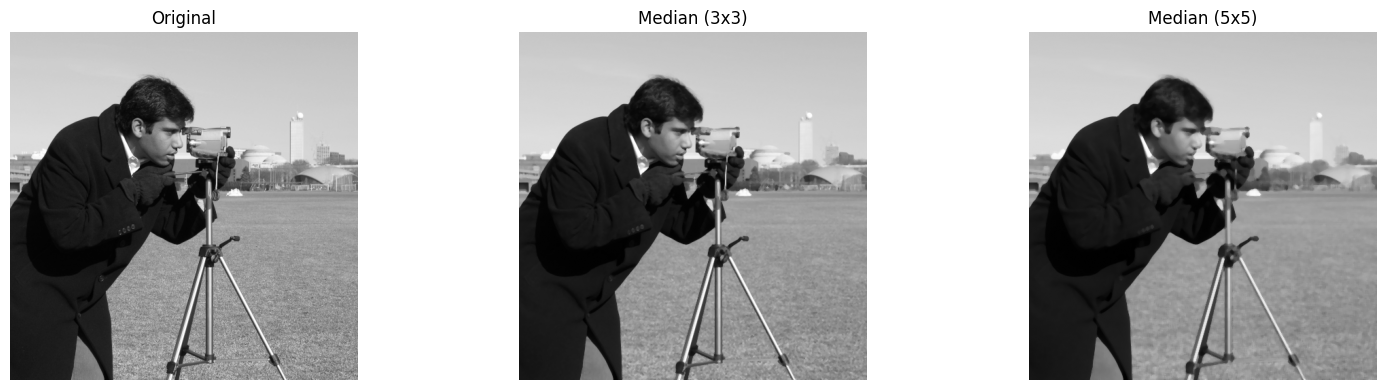

In [3]:
# Vamos pegar alguns kernels da aula
K3x3 = np.ones((3, 3), dtype=np.float64)

K5x5 = np.ones((5, 5), dtype=np.float64)

def medianImage(img, kernel):
    """Filtro da mediana de uma imagem em nivel de cinza."""
    res = median(img, kernel)
    return res

resMedian3x3 = medianImage(camera, K3x3)

resMedian5x5 = medianImage(camera, K5x5)

show_images(
    [camera, resMedian3x3, resMedian5x5],
    titles=["Original", "Median (3x3)", "Median (5x5)"],
    cmap='gray',
    figsize=(16, 4)
)


### Filtro da mediana com loops

Complete o código com a função de mediana do numpy.

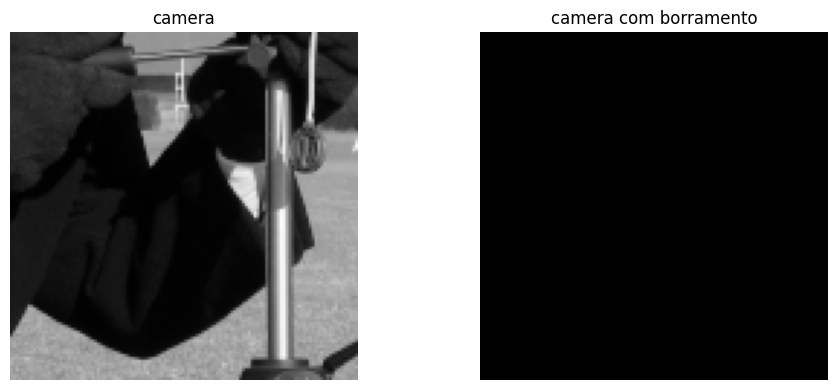

In [4]:
def medianWLoop(img, kernel):
    """Filtro da mediana (zero padding). O kernel precisa ter lados ímpares."""
    # Mudando os tipos para usar numpy
    img = img.astype(np.float64)
    k = kernel.astype(np.float64)
    # Tomando as dimensoes e verificando se o kernel tem as dimensoes corretas
    kh, kw = k.shape
    assert (kh % 2 == 1) and (kw % 2 == 1)
    # zero-padding
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    outImage = np.zeros_like(img, dtype=np.float64)

    H, W = img.shape
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+kh, j:j+kw]
            outImage[i, j] = 0 # Troque pela função correta
    return outImage

cameraSmall = camera[200:320, 200:320]
resMedianCamera = medianWLoop(cameraSmall, K3x3)

show_images(
    [cameraSmall, resMedianCamera],
    titles=["camera", "camera com borramento"],
    cmap='gray',
    figsize=(10, 4)
)


## Exercícios extras

1. **Filtro da Mediana**
   - Experimente comparar com um filtro da média com kernel 5×5 e 3×3.
   - Experimente comparar com o filtro Gaussiano com a função `skimage.filters.gaussian`.

In [5]:
from google.colab import files
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np

uploaded = files.upload()

imagens = []
for nome_arquivo in uploaded.keys():
    img = imread(nome_arquivo)
    if len(img.shape) == 3:
        img = rgb2gray(img)
    imagens.append(img)

print(f"{len(imagens)} imagens carregadas com sucesso.")


Saving sandalia2_3.jpg to sandalia2_3.jpg
Saving sandalia2_1.jpg to sandalia2_1.jpg
Saving sandalia2_2.jpg to sandalia2_2.jpg
Saving sandalia1_3.jpg to sandalia1_3.jpg
Saving sandalia1_2.jpg to sandalia1_2.jpg
Saving sandalia1_1.jpg to sandalia1_1.jpg
Saving tenis2_3.jpg to tenis2_3.jpg
Saving tenis2_2.jpg to tenis2_2.jpg
Saving tenis2_1.jpg to tenis2_1.jpg
Saving tenis1_3.jpg to tenis1_3.jpg
Saving tenis1_2.jpg to tenis1_2.jpg
Saving tenis1_1.jpg to tenis1_1.jpg
12 imagens carregadas com sucesso.


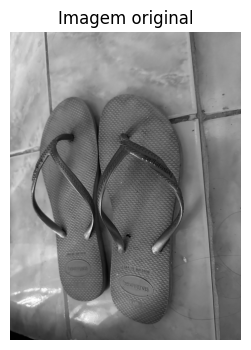

In [6]:
plt.figure(figsize=(4,4))
plt.imshow(imagens[0], cmap='gray')
plt.title("Imagem original")
plt.axis('off')
plt.show()


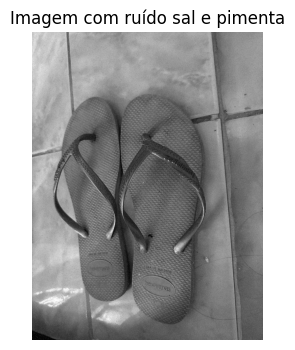

In [8]:
from skimage.util import random_noise

img = imagens[0]
img_ruido = random_noise(img, mode='s&p', amount=0.05)

plt.figure(figsize=(4,4))
plt.imshow(img_ruido, cmap='gray')
plt.title("Imagem com ruído sal e pimenta")
plt.axis('off')
plt.show()



/tmp/ipython-input-322433013.py:5: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  img_mediana = median(img_ruido, square(3))


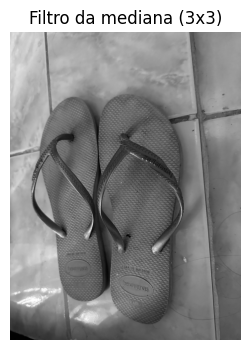

In [9]:
#Filtro da Mediana (não linear)
from skimage.filters import median
from skimage.morphology import square

img_mediana = median(img_ruido, square(3))

plt.figure(figsize=(4,4))
plt.imshow(img_mediana, cmap='gray')
plt.title("Filtro da mediana (3x3)")
plt.axis('off')
plt.show()

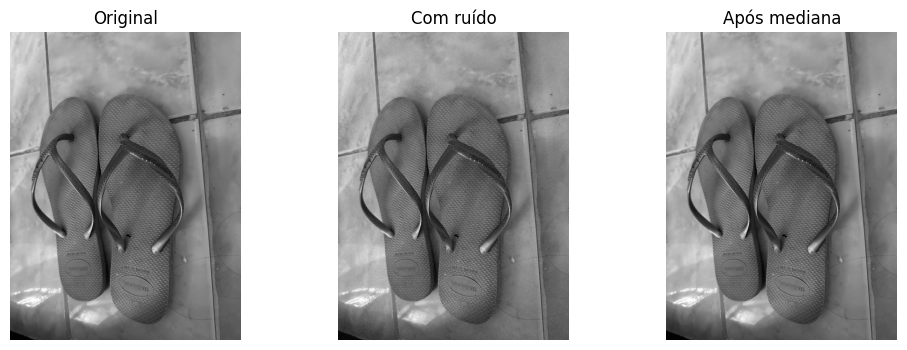

In [10]:
# Comparação: Original x Ruído x Mediana
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_ruido, cmap='gray')
plt.title("Com ruído")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_mediana, cmap='gray')
plt.title("Após mediana")
plt.axis('off')

plt.show()

In [11]:
# Filtro Mínimo e Máximo (ordem estatística)
from skimage.filters.rank import minimum, maximum
from skimage.morphology import disk

se = disk(2)

img_min = minimum((img_ruido*255).astype(np.uint8), se)
img_max = maximum((img_ruido*255).astype(np.uint8), se)

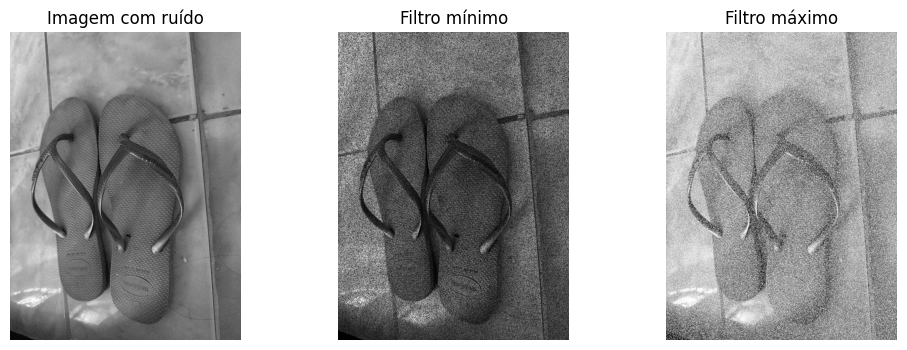

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_ruido, cmap='gray')
plt.title("Imagem com ruído")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_min, cmap='gray')
plt.title("Filtro mínimo")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_max, cmap='gray')
plt.title("Filtro máximo")
plt.axis('off')

plt.show()


/tmp/ipython-input-3893588149.py:4: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  img2_mediana = median(img2_ruido, square(3))


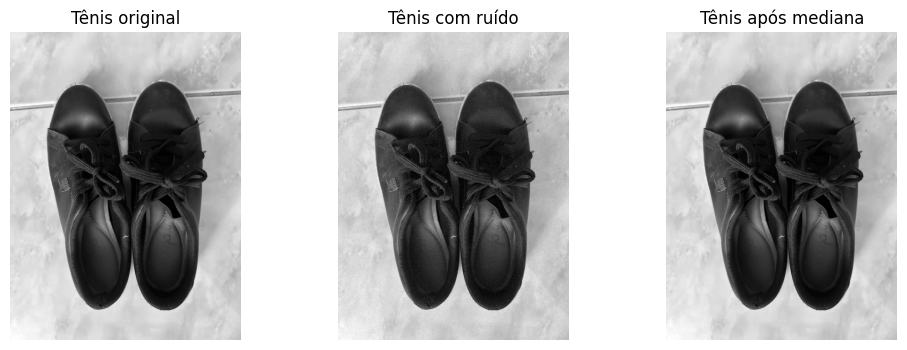

In [13]:
# tênis
img2 = imagens[8]
img2_ruido = random_noise(img2, mode='s&p', amount=0.05)
img2_mediana = median(img2_ruido, square(3))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img2, cmap='gray')
plt.title("Tênis original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img2_ruido, cmap='gray')
plt.title("Tênis com ruído")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img2_mediana, cmap='gray')
plt.title("Tênis após mediana")
plt.axis('off')

plt.show()

In [14]:
# Kernels da média
kernel3 = np.ones((3,3)) / 9
kernel5 = np.ones((5,5)) / 25

def conv2d(imagem, kernel):
    h, w = imagem.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    imagem_pad = np.pad(imagem, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    resultado = np.zeros_like(imagem)

    for i in range(h):
        for j in range(w):
            regiao = imagem_pad[i:i+kh, j:j+kw]
            resultado[i, j] = np.sum(regiao * kernel)

    return resultado

media3 = conv2d(img_ruido, kernel3)
media5 = conv2d(img_ruido, kernel5)


In [15]:
# Gaussiano
from skimage.filters import gaussian

gauss = gaussian(img_ruido, sigma=1)

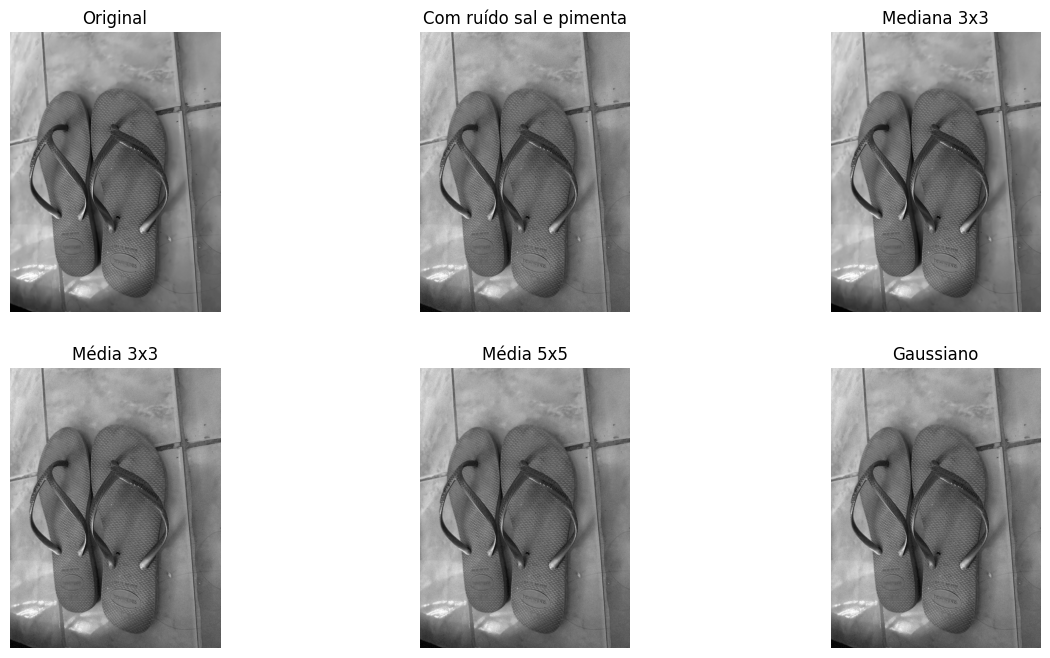

In [16]:
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(img_ruido, cmap='gray')
plt.title("Com ruído sal e pimenta")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(img_mediana, cmap='gray')
plt.title("Mediana 3x3")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(media3, cmap='gray')
plt.title("Média 3x3")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(media5, cmap='gray')
plt.title("Média 5x5")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(gauss, cmap='gray')
plt.title("Gaussiano")
plt.axis('off')

plt.show()

/tmp/ipython-input-2066233570.py:5: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  se = square(3)


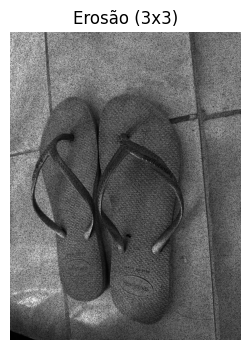

In [17]:
# blocos extra: Erosão morfológica
from skimage.morphology import erosion, dilation, square

# Elemento estruturante 3x3
se = square(3)

img_erosao = erosion((img_ruido*255).astype(np.uint8), footprint=se)

plt.figure(figsize=(4,4))
plt.imshow(img_erosao, cmap='gray')
plt.title("Erosão (3x3)")
plt.axis('off')
plt.show()

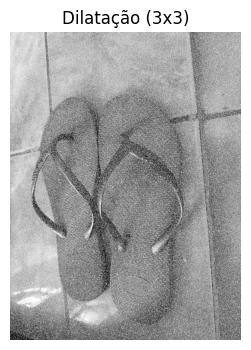

In [18]:
# Dilatação morfológica
img_dilatacao = dilation((img_ruido*255).astype(np.uint8), footprint=se)

plt.figure(figsize=(4,4))
plt.imshow(img_dilatacao, cmap='gray')
plt.title("Dilatação (3x3)")
plt.axis('off')
plt.show()

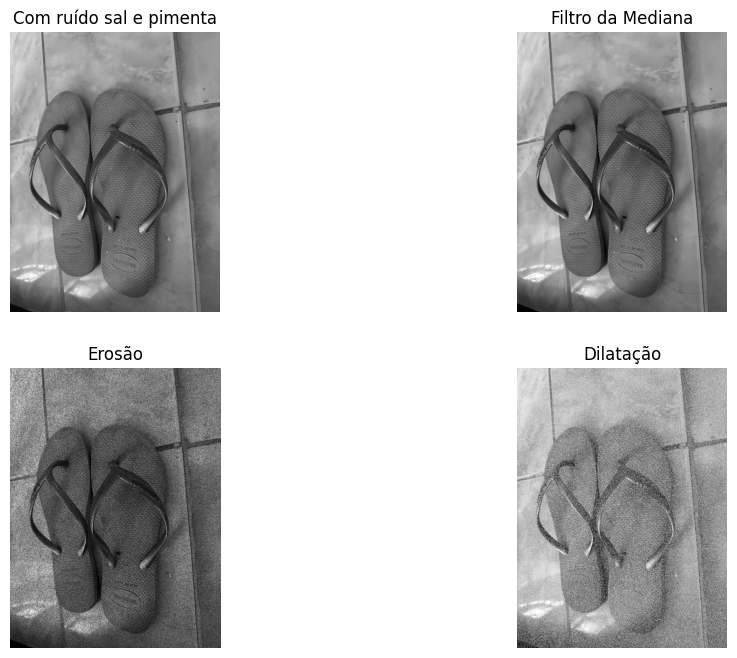

In [19]:
# Comparação completa: ruído, mediana, erosão, dilatação
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_ruido, cmap='gray')
plt.title("Com ruído sal e pimenta")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_mediana, cmap='gray')
plt.title("Filtro da Mediana")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_erosao, cmap='gray')
plt.title("Erosão")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img_dilatacao, cmap='gray')
plt.title("Dilatação")
plt.axis('off')

plt.show()